# 04 — Analysis of MD Simulations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/Module%202%20-%20Molecular%20dynamics/notebooks/04_analysis_of_simulations.ipynb)

## Learning Objectives
1. **Equilibration** of a system by monitoring thermodynamic observables over time and applying block averaging.
2. **Extract thermodynamic properties** — temperature, pressure, and heat capacity — from a molecular dynamics trajectory.
3. **Radial distribution function (RDF)** and coordination numbers for structural analysis.
4. **Time-correlation functions** (VACF) and the vibrational density of states (VDOS) via FFT.
6. **Diffusion coefficient** using both the Einstein (MSD) and Green-Kubo (VACF integral) relations.
7. **Statistical errors** rigorously using block averaging on correlated data.

In [1]:
# Ch121a: Molecular Dynamics — Notebook 04: Analysis of MD Simulations
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.fft import fft, fftfreq
from scipy.signal import correlate, correlation_lags

rng = np.random.default_rng(42)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print('Imports successful.')

Imports successful.


---
## Section 1: Equilibration

### Equilibration vs. Production

Before collecting statistics, an MD simulation must **equilibrate**: the system must lose memory of its
initial (often artificial) configuration and reach a representative sample of the target ensemble.

#### How to detect equilibration

| Observable | What to watch for |
|---|---|
| Potential energy $U(t)$ | Stable plateau; no drift |
| Kinetic temperature $T(t)$ | Fluctuates around target $T$ |
| Density $\rho(t)$ (NPT) | Converged to experimental value |
| Pressure $P(t)$ | Stable mean with bounded fluctuations |

**Visual inspection** remains the most robust first check: plot each observable vs. simulation time and
look for a stationary plateau.

#### Autocorrelation time

The **autocorrelation time** $\tau_A$ of an observable $A$ is:
$$\tau_A = \int_0^\infty C_A(t)\,dt, \qquad C_A(t) = \frac{\langle \delta A(0)\,\delta A(t)\rangle}{\langle (\delta A)^2\rangle}$$
where $\delta A = A - \langle A\rangle$.  Data points separated by $< \tau_A$ are correlated and should
**not** be treated as independent samples.

#### Block averaging

Divide the production trajectory into $B$ non-overlapping blocks, each of length
$\tau_{\text{block}} \gg \tau_A$.  Block averages $\bar{A}_b$ are approximately independent, so the
standard error of the mean is:
$$\sigma_{\langle A\rangle} = \frac{\text{std}(\bar{A}_b)}{\sqrt{B}}$$

#### Typical equilibration times

- Simple liquids (LJ argon): 10–100 ps  
- Water at ambient conditions: 0.1–1 ns  
- Proteins / biomolecules: 10 ns–1 µs  
- Polymers / glasses: µs–ms (often not fully equilibrated in practice)

In [2]:
# ── Langevin dynamics in 1D (dimensionless units: m=1, k_BT=1, γ=1) ──
# Physical reference: T=300 K  →  k_BT = 0.0259 eV = 0.596 kcal/mol
#                      mass = 18 amu (water molecule)
#                      dt   = 1 fs = 1e-15 s
#
# Langevin equation (velocity Verlet-like discretisation):
#   v(t+dt) = v(t) + [-γ v(t) + sqrt(2γ k_BT/m)/dt * ξ] * dt
#   x(t+dt) = x(t) + v(t+dt) * dt
# In dimensionless units (m=1, k_BT=1, γ=1, dt=0.01):
#   v += (-γ*v + sqrt(2γ) * ξ/sqrt(dt)) * dt

N_particles = 50
N_steps     = 10_000
dt          = 0.01      # dimensionless timestep
gamma       = 1.0       # friction coefficient (dimensionless)
kBT         = 1.0       # thermal energy (dimensionless)
mass        = 1.0       # particle mass (dimensionless)

# Initialise positions and velocities
pos = rng.standard_normal((N_particles,))  # x_0
vel = rng.standard_normal((N_particles,)) * np.sqrt(kBT / mass)  # Maxwell-Boltzmann

# Storage arrays
pos_traj = np.zeros((N_steps, N_particles))
vel_traj = np.zeros((N_steps, N_particles))

noise_amplitude = np.sqrt(2.0 * gamma * kBT / mass)  # sigma of random force

for step in range(N_steps):
    # Random force (Gaussian white noise)
    xi = rng.standard_normal(N_particles)
    # Langevin update
    force = -gamma * vel + noise_amplitude * xi / np.sqrt(dt)
    vel = vel + force * dt
    pos = pos + vel * dt
    pos_traj[step] = pos
    vel_traj[step] = vel

time = np.arange(N_steps) * dt
print(f'Langevin trajectory: {N_steps} steps × {N_particles} particles')
print(f'Total simulation time: {time[-1]:.1f} (dimensionless units)')

Langevin trajectory: 10000 steps × 50 particles
Total simulation time: 100.0 (dimensionless units)


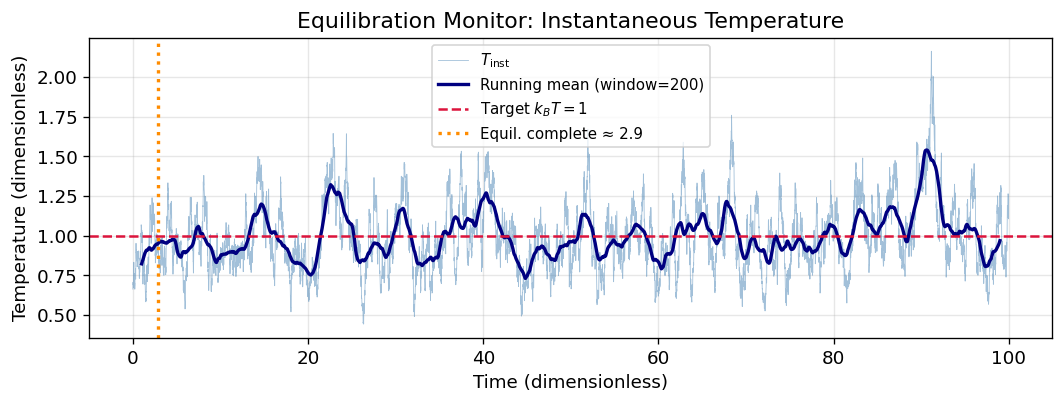

Equilibration detected at t ≈ 2.88  (step ≈ 288)


In [3]:
# Instantaneous temperature from KE:  T_inst = m*<v²> / k_B  (1D: N_dof = N)
KE_inst  = 0.5 * mass * np.mean(vel_traj**2, axis=1)   # KE per particle
T_inst   = 2.0 * KE_inst / 1.0                          # 1 DoF per particle in 1D

# Running mean
window   = 200
T_running = np.convolve(T_inst, np.ones(window)/window, mode='valid')
t_running = time[window//2 : window//2 + len(T_running)]

# Simple heuristic: equilibration complete when running mean stays within 5 % of target
equil_idx = next(
    (i for i in range(len(T_running))
     if abs(T_running[i] - kBT) / kBT < 0.05),
    len(T_running) // 2
)
t_equil = t_running[equil_idx]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(time, T_inst, lw=0.5, alpha=0.5, color='steelblue', label='$T_{\\mathrm{inst}}$')
ax.plot(t_running, T_running, lw=2, color='navy', label=f'Running mean (window={window})')
ax.axhline(kBT, ls='--', color='crimson', lw=1.5, label='Target $k_BT=1$')
ax.axvline(t_equil, ls=':', color='darkorange', lw=2, label=f'Equil. complete ≈ {t_equil:.1f}')
ax.set_xlabel('Time (dimensionless)')
ax.set_ylabel('Temperature (dimensionless)')
ax.set_title('Equilibration Monitor: Instantaneous Temperature')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'Equilibration detected at t ≈ {t_equil:.2f}  (step ≈ {int(t_equil/dt)})')

---
## Section 2: Thermodynamic Properties

### 2.1 Temperature from Kinetic Energy

The **instantaneous kinetic temperature** is defined via the equipartition theorem:
$$T_{\text{inst}} = \frac{2\langle KE\rangle}{N_{\text{dof}}\,k_B}, \qquad KE = \frac{1}{2}\sum_i m_i v_i^2$$

The number of degrees of freedom $N_{\text{dof}} = 3N - N_c$, where $N_c = 3$ constraints are removed
when fixing the centre-of-mass momentum (3 translational DoFs).

**Equipartition theorem:** each independent quadratic degree of freedom contributes $\tfrac{1}{2}k_BT$
to the average energy:
$$\left\langle \frac{1}{2}m_i v_{i,\alpha}^2 \right\rangle = \frac{1}{2}k_BT \quad \forall\, i,\alpha$$

This holds **exactly** in the canonical (NVT) ensemble and is the basis for thermostat algorithms
(Nosé–Hoover, Langevin, Andersen) that couple the system to a heat bath.

### 2.2 Pressure via the Virial Theorem

For a classical $N$-body system in volume $V$, the **mechanical pressure** is:
$$PV = Nk_BT + \underbrace{\frac{1}{3}\left\langle \sum_{i} \mathbf{r}_i \cdot \mathbf{F}_i \right\rangle}_{\text{virial } \mathcal{W}}$$

- The first term is the **ideal-gas** contribution.
- $\mathcal{W}$ is the **virial** — the sum over all pair interactions:
  $\mathcal{W} = \tfrac{1}{3}\sum_{i<j} \mathbf{r}_{ij}\cdot\mathbf{F}_{ij}$
- For a LJ fluid: $\mathcal{W} < 0$ at low $T$ (attractive regime) → $P < P_{\text{ideal}}$.
- For a repulsive soft-sphere fluid: $\mathcal{W} > 0$ → $P > P_{\text{ideal}}$.

In NPT simulations the cell volume fluctuates and $P$ is controlled by a barostat (Parrinello–Rahman,
Monte Carlo volume moves).

### 2.3 Heat Capacity at Constant Volume

The isochoric heat capacity can be computed from **energy fluctuations** (canonical ensemble):
$$C_V = \frac{\langle (\delta E)^2\rangle}{k_B T^2} = \frac{\langle E^2\rangle - \langle E\rangle^2}{k_B T^2}$$

This **fluctuation formula** is the finite-difference analogue of $C_V = (\partial U/\partial T)_V$
and is valid in the NVT ensemble.

**Limiting cases:**

| System | $C_V$ |
|---|---|
| Monatomic ideal gas | $\frac{3}{2}Nk_B$ |
| Diatomic ideal gas (rigid) | $\frac{5}{2}Nk_B$ |
| Harmonic crystal (Dulong–Petit) | $3Nk_B$ |
| Liquid water (experimental) | $\approx 9 k_B$ per molecule |

Deviations from the ideal-gas value signal **interactions** and **molecular degrees of freedom**.

Production steps : 9712
⟨T⟩              : 0.9954  (target kBT = 1.0)
σ_T              : 0.2187
C_V (fluctuation): 29.88
C_V (equipartition, 1D): 25.00  [N/2 for 1D free particles]


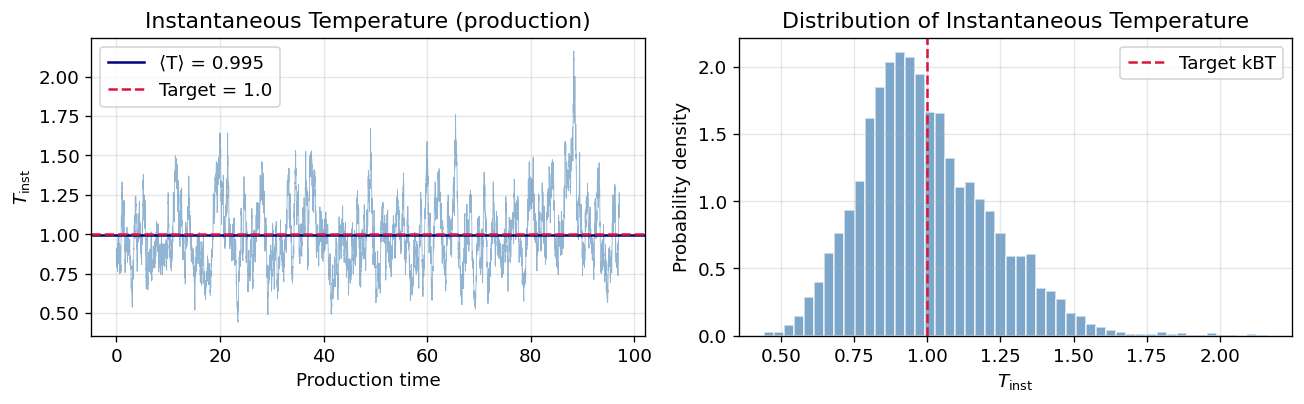

In [4]:
# Use only the production portion (after equilibration)
equil_step = int(t_equil / dt)
vel_prod   = vel_traj[equil_step:]
N_prod     = len(vel_prod)

# Instantaneous temperature (1 DoF per particle in 1D)
KE_prod  = 0.5 * mass * vel_prod**2           # shape (N_prod, N_particles)
KE_total = KE_prod.sum(axis=1)                # total KE per snapshot
T_prod   = 2.0 * KE_total / N_particles        # T_inst

T_mean   = T_prod.mean()
T_std    = T_prod.std()

# Heat capacity from energy fluctuations  C_V = Var(E) / (k_BT^2)
# In dimensionless units: k_B = 1
E_prod   = KE_total          # (no potential energy in free Langevin)
C_V      = E_prod.var() / (kBT**2)
C_V_equip = 0.5 * N_particles    # equipartition: N/2 for 1D (k_B=1)

print(f'Production steps : {N_prod}')
print(f'⟨T⟩              : {T_mean:.4f}  (target kBT = {kBT})')
print(f'σ_T              : {T_std:.4f}')
print(f'C_V (fluctuation): {C_V:.2f}')
print(f'C_V (equipartition, 1D): {C_V_equip:.2f}  [N/2 for 1D free particles]')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

t_prod = np.arange(N_prod) * dt
axes[0].plot(t_prod, T_prod, lw=0.5, alpha=0.6, color='steelblue')
axes[0].axhline(T_mean, color='navy', lw=1.5, label=f'⟨T⟩ = {T_mean:.3f}')
axes[0].axhline(kBT, ls='--', color='crimson', lw=1.5, label=f'Target = {kBT}')
axes[0].set_xlabel('Production time')
axes[0].set_ylabel('$T_{\\mathrm{inst}}$')
axes[0].set_title('Instantaneous Temperature (production)')
axes[0].legend()

axes[1].hist(T_prod, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(kBT, ls='--', color='crimson', lw=1.5, label=f'Target kBT')
axes[1].set_xlabel('$T_{\\mathrm{inst}}$')
axes[1].set_ylabel('Probability density')
axes[1].set_title('Distribution of Instantaneous Temperature')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Section 3: Structural Analysis — Radial Distribution Function

### 3.1 Definition of g(r)

The **radial distribution function** $g(r)$ measures the probability of finding a particle at
distance $r$ from a reference particle, relative to an ideal gas at the same density:

$$g(r) = \frac{V}{N^2}\left\langle \sum_{i \neq j} \delta(r - r_{ij})\right\rangle$$

In practice it is computed as a histogram:
$$g(r) = \frac{\Delta n(r)}{N\,\rho\,4\pi r^2\,\Delta r}, \qquad \rho = N/V$$

where $\Delta n(r)$ is the number of pairs with separation in $[r, r+\Delta r]$.

**Properties:**
- $g(r) \to 1$ as $r \to \infty$ in a uniform fluid (no long-range order).
- $g(r) = 0$ for $r < \sigma$ (hard-core exclusion).
- Peaks at preferred interparticle distances.

**Coordination number** from the first peak:
$$n_1 = 4\pi\rho \int_0^{r_{\min}} g(r)\,r^2\,dr$$
where $r_{\min}$ is the first minimum of $g(r)$.

**Physical examples:**
- **Ideal gas**: $g(r) = 1$ everywhere.
- **LJ liquid**: first peak near $r^* \approx 1.1\sigma$, second peak ~$2\sigma$, $g\to 1$ beyond ~$3\sigma$.
- **Water**: first peak at 2.8 Å (O–O), coordination number ~4.5 (tetrahedral).
- **Crystal**: sharp $\delta$-function peaks at lattice spacings.

Placed 200 particles in a 20³ Å³ box  (ρ = 0.0250 Å⁻³)


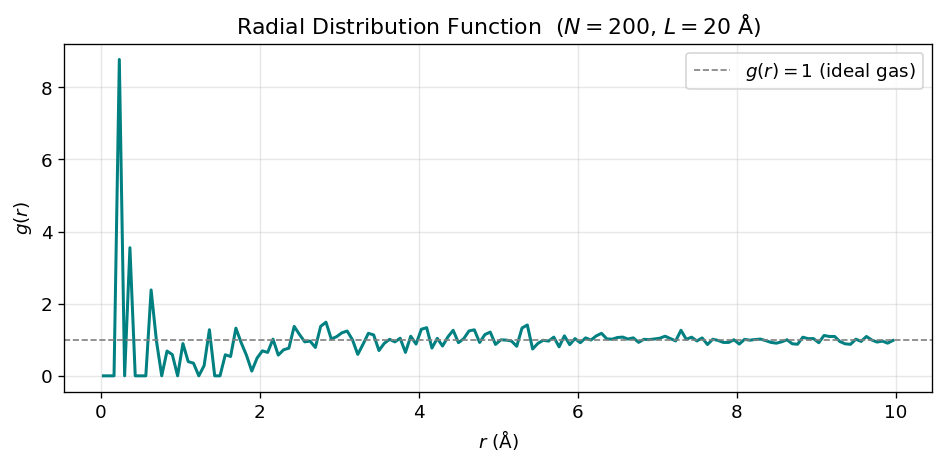

In [5]:
# ── Generate N=200 particles in a 3D cubic box with liquid-like packing ──
N_rdf    = 200
L_box    = 20.0          # Angstrom; gives ρ = N/V = 200/8000 = 0.025 Å⁻³
rho_bulk = N_rdf / L_box**3

# Simple MC-like initialisation: reject overlaps closer than sigma=2.5 Å
sigma    = 2.5           # Angstrom (LJ diameter)
r_min_sq = (0.9 * sigma)**2

coords = []
attempts = 0
while len(coords) < N_rdf and attempts < 200_000:
    attempts += 1
    trial = rng.uniform(0, L_box, size=3)
    accepted = True
    for p in coords[-50:]:   # check against recent 50 to keep O(N)
        dr = trial - p
        dr -= L_box * np.round(dr / L_box)   # minimum image
        if np.dot(dr, dr) < r_min_sq:
            accepted = False
            break
    if accepted:
        coords.append(trial)

coords = np.array(coords)
N_actual = len(coords)
print(f'Placed {N_actual} particles in a {L_box:.0f}³ Å³ box  (ρ = {N_actual/L_box**3:.4f} Å⁻³)')

# ── Compute g(r) ──────────────────────────────────────────────────────────────
r_max  = L_box / 2.0    # max range (half-box, minimum image convention)
n_bins = 150
r_edges = np.linspace(0, r_max, n_bins + 1)
dr      = r_edges[1] - r_edges[0]
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

hist = np.zeros(n_bins)
for i in range(N_actual - 1):
    diffs = coords[i+1:] - coords[i]                  # all pairs with j>i
    diffs -= L_box * np.round(diffs / L_box)           # minimum image
    dist  = np.sqrt((diffs**2).sum(axis=1))
    h, _  = np.histogram(dist, bins=r_edges)
    hist += h

hist *= 2   # count each pair once → double for i<j convention

# Normalise: g(r) = hist / (N * rho * 4π r² dr)
shell_vol = 4.0 * np.pi * r_centers**2 * dr
g_r = hist / (N_actual * rho_bulk * shell_vol)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_centers, g_r, color='teal', lw=1.8)
ax.axhline(1.0, ls='--', color='gray', lw=1, label='$g(r)=1$ (ideal gas)')
ax.set_xlabel('$r$ (Å)')
ax.set_ylabel('$g(r)$')
ax.set_title(f'Radial Distribution Function  ($N={N_actual}$, $L={L_box:.0f}$ Å)')
ax.legend()
plt.tight_layout()
plt.show()

First minimum of g(r) at r = 2.70 Å
Coordination number (1st shell): n₁ = 1.56


/tmp/ipykernel_402474/2207571567.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  n_coord = 4.0 * np.pi * rho_bulk * np.trapz(g_r[mask] * r_centers[mask]**2,


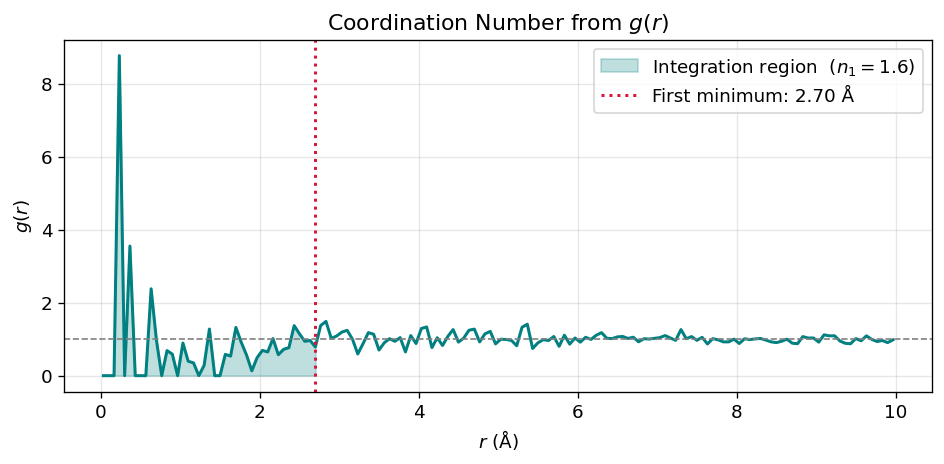

In [6]:
# ── Coordination number from integral up to first minimum ────────────────
# Locate first minimum of g(r) after the first peak
from scipy.signal import argrelmin

# Only look beyond the exclusion zone (r > 2σ)
start_idx = np.searchsorted(r_centers, 1.0 * sigma)
g_search  = g_r[start_idx:]

minima = argrelmin(g_search, order=3)[0]
if len(minima) > 0:
    first_min_idx = start_idx + minima[0]
    r_min1        = r_centers[first_min_idx]
else:
    # fallback: integrate up to 1.5 * sigma_LJ
    r_min1     = 1.5 * sigma * 2  # rough guess
    first_min_idx = np.searchsorted(r_centers, r_min1)

# Coordination number: n = 4π ρ ∫₀^{r_min} g(r) r² dr
mask  = r_centers <= r_min1
n_coord = 4.0 * np.pi * rho_bulk * np.trapz(g_r[mask] * r_centers[mask]**2,
                                              r_centers[mask])

print(f'First minimum of g(r) at r = {r_min1:.2f} Å')
print(f'Coordination number (1st shell): n₁ = {n_coord:.2f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_centers, g_r, color='teal', lw=1.8)
ax.fill_between(r_centers[mask], 0, g_r[mask], alpha=0.25, color='teal',
                label=f'Integration region  ($n_1={n_coord:.1f}$)')
ax.axvline(r_min1, ls=':', color='crimson', lw=1.8, label=f'First minimum: {r_min1:.2f} Å')
ax.axhline(1.0, ls='--', color='gray', lw=1)
ax.set_xlabel('$r$ (Å)')
ax.set_ylabel('$g(r)$')
ax.set_title('Coordination Number from $g(r)$')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4: Time-Correlation Functions

### 4.1 Definition

The **time-correlation function (TCF)** between observables $A$ and $B$ is:
$$C_{AB}(t) = \langle A(0)\,B(t)\rangle$$

In equilibrium the system is **stationary**: $C_{AB}(t) = \langle A(s)\,B(s+t)\rangle$ for any $s$,
allowing efficient computation by averaging over many time origins.

The **normalised autocorrelation function** is:
$$C_A(t) = \frac{\langle A(0)\,A(t)\rangle}{\langle A^2\rangle}, \qquad C_A(0) = 1$$

The **relaxation time** (integrated autocorrelation time):
$$\tau_A = \int_0^\infty C_A(t)\,dt$$

**Physical examples:**

| TCF | Green-Kubo transport coefficient |
|---|---|
| VACF $\langle v(0)v(t)\rangle$ | Diffusion coefficient $D$ |
| Stress-stress $\langle \sigma(0)\sigma(t)\rangle$ | Shear viscosity $\eta$ |
| Current-current $\langle J(0)J(t)\rangle$ | Electrical conductivity $\sigma$ |
| Heat-flux $\langle J_q(0)J_q(t)\rangle$ | Thermal conductivity $\lambda$ |

### 4.2 Velocity Autocorrelation Function (VACF)

The VACF is defined as:
$$C_v(t) = \frac{\langle \mathbf{v}(0)\cdot\mathbf{v}(t)\rangle}{\langle v^2\rangle}$$

**Physical regimes:**

1. **Ballistic** ($t \to 0$): $C_v(t) \approx 1 - \omega_E^2 t^2/2$, where $\omega_E$ is the
   Einstein frequency. Particle moves freely.

2. **Oscillatory** (solids / high-density liquids): $C_v(t)$ oscillates around zero — particle is
   'caged' and bounces back.

3. **Negative dip** (dense liquids): backscattering from cage causes a negative lobe before recovery.

4. **Diffusive** ($t \to \infty$): exponential decay $C_v(t) \approx e^{-t/\tau}$ in simple liquids.

**Connection to diffusion (Green-Kubo):**
$$D = \int_0^\infty \langle v_x(0)\,v_x(t)\rangle\,dt \quad \text{(1D)}$$
$$D = \frac{1}{3}\int_0^\infty \langle \mathbf{v}(0)\cdot\mathbf{v}(t)\rangle\,dt \quad \text{(3D)}$$

### 4.3 Power Spectrum and Vibrational Density of States (VDOS)

The **vibrational density of states** (VDOS) is the Fourier transform of the VACF
(Wiener–Khinchin theorem):
$$S(\omega) = \int_{-\infty}^{+\infty} C_v(t)\,e^{i\omega t}\,dt = \mathcal{F}[C_v(t)]$$

**Physical interpretation:**
- $S(\omega)$ at frequency $\omega$ counts the number of vibrational modes available at that frequency.
- Sharp peaks → well-defined vibrational modes (e.g., O–H stretch at ~3400 cm⁻¹ in water).
- Broad features → overdamped modes / diffusion.
- $S(0) > 0$ → diffusive behaviour; $S(0) = 0$ → purely vibrational (solid-like).

**Frequency conversion:**
$$\tilde{\nu}\,(\text{cm}^{-1}) = \frac{\omega}{2\pi c}, \quad c = 3\times 10^{10}\,\text{cm/s}$$

The VDOS from MD can be directly compared to **IR and Raman spectra** (with appropriate selection
rules), making it a powerful tool for spectroscopic assignment.

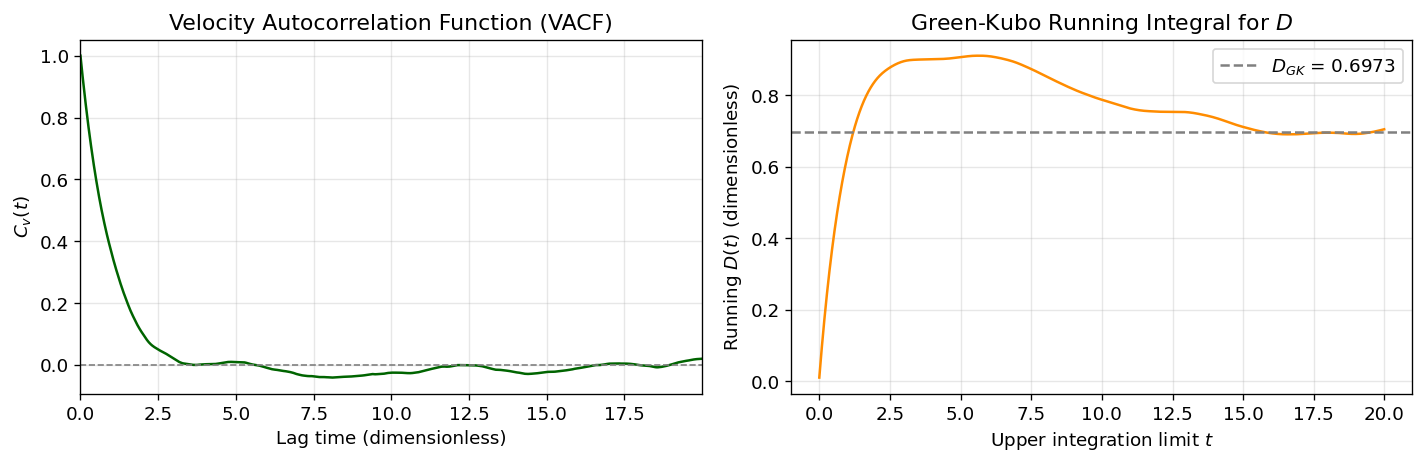

Green-Kubo diffusion coefficient (Langevin, 1D): D_GK = 0.69733
Theoretical (free Langevin): D_theory = kBT/γ = 1.0000


In [7]:
# ── Compute VACF from Langevin trajectory ──────────────────────────────────
# Use a windowed estimator: average over multiple time origins

# Take a single representative particle's velocity trace
# (could also average over all particles — we do both)
v_all  = vel_traj[equil_step:]   # shape (N_prod, N_particles)
N_max_lag = min(2000, N_prod // 2)   # max lag for VACF

# Efficient VACF via FFT-based autocorrelation (averaged over particles)
def compute_vacf_fft(v_series, max_lag):
    """VACF via FFT. v_series: (N_time, N_part). Returns normalised C_v[0:max_lag]."""
    N, P   = v_series.shape
    n_fft  = 2 * N   # zero-pad to avoid circular correlation
    V_fft  = np.fft.rfft(v_series, n=n_fft, axis=0)
    power  = (V_fft * V_fft.conj()).real          # |FFT|^2, shape (n_fft//2+1, P)
    acf    = np.fft.irfft(power, n=n_fft, axis=0) # autocorrelation (unnormalised)
    acf    = acf[:N]                               # positive lags only
    # Normalise by number of time origins contributing to each lag
    norm   = np.arange(N, 0, -1)[:, None]         # (N, 1)
    acf    = acf / norm
    c_v    = acf.mean(axis=1)                      # average over particles
    c_v   /= c_v[0]                                # normalise C_v(0) = 1
    return c_v[:max_lag]

VACF    = compute_vacf_fft(v_all, N_max_lag)
t_vacf  = np.arange(N_max_lag) * dt

# Running integral → D(t) = ∫₀ᵗ C_v(t') * <v²> dt'
v2_mean   = np.mean(v_all**2)
D_running = np.cumsum(VACF * v2_mean) * dt   # Green-Kubo running integral

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_vacf, VACF, lw=1.5, color='darkgreen')
axes[0].axhline(0, ls='--', color='gray', lw=1)
axes[0].set_xlabel('Lag time (dimensionless)')
axes[0].set_ylabel('$C_v(t)$')
axes[0].set_title('Velocity Autocorrelation Function (VACF)')
axes[0].set_xlim(0, min(20, t_vacf[-1]))

axes[1].plot(t_vacf, D_running, lw=1.5, color='darkorange')
axes[1].axhline(D_running[-100:].mean(), ls='--', color='gray', lw=1.5,
                label=f'$D_{{GK}}$ = {D_running[-100:].mean():.4f}')
axes[1].set_xlabel('Upper integration limit $t$')
axes[1].set_ylabel('Running $D(t)$ (dimensionless)')
axes[1].set_title('Green-Kubo Running Integral for $D$')
axes[1].legend()

plt.tight_layout()
plt.show()

D_GK_langevin = D_running[-100:].mean()
print(f'Green-Kubo diffusion coefficient (Langevin, 1D): D_GK = {D_GK_langevin:.5f}')
print(f'Theoretical (free Langevin): D_theory = kBT/γ = {kBT/gamma:.4f}')

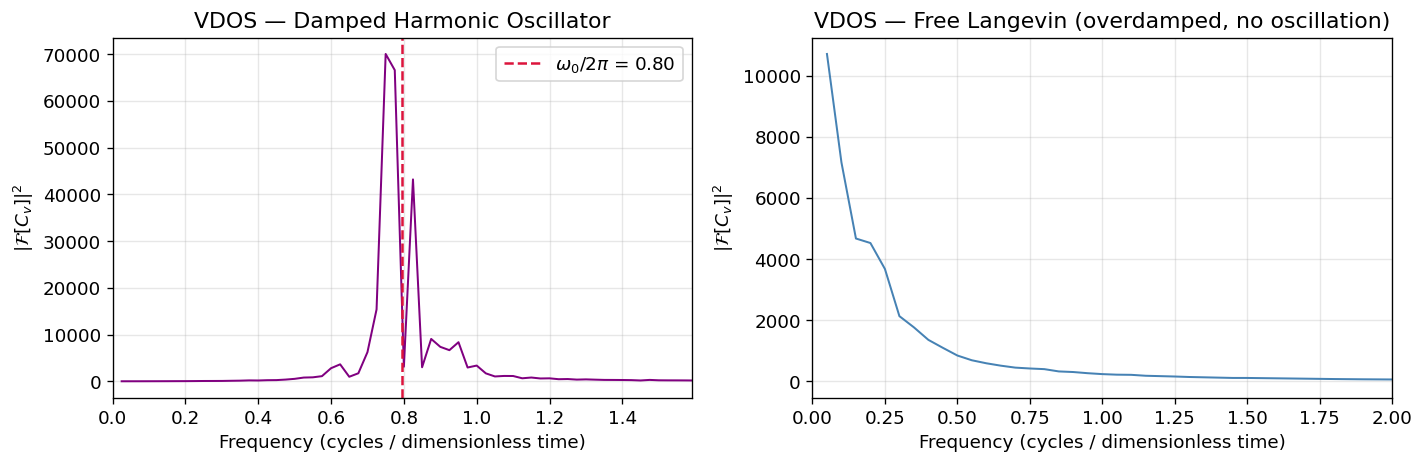

Harmonic oscillator peak at ω₀/2π = 0.796


In [8]:
# ── Power spectrum / VDOS via FFT of VACF ──────────────────────────────────
# For a clearer peak, also compute VACF of a damped harmonic oscillator
# Equation of motion: dv/dt = -γv - ω₀²x + noise

omega0  = 5.0    # natural frequency (dimensionless)
gamma_ho = 0.5   # damping
N_ho    = 8_000
dt_ho   = 0.01

x_ho = np.zeros(N_ho)
v_ho = np.zeros(N_ho)
x_ho[0] = rng.standard_normal()
v_ho[0] = rng.standard_normal()

noise_ho = rng.standard_normal(N_ho) * np.sqrt(2 * gamma_ho * kBT / (mass * dt_ho))
for i in range(N_ho - 1):
    a = -gamma_ho * v_ho[i] - omega0**2 * x_ho[i] + noise_ho[i]
    v_ho[i+1] = v_ho[i] + a * dt_ho
    x_ho[i+1] = x_ho[i] + v_ho[i+1] * dt_ho

# VACF of harmonic oscillator
v_ho_2d = v_ho[:, None]   # shape (N_ho, 1)
VACF_ho  = compute_vacf_fft(v_ho_2d, N_ho // 2)
t_ho     = np.arange(len(VACF_ho)) * dt_ho

# FFT → VDOS
n_fft_vdos = len(VACF_ho)
VDOS_ho    = np.abs(fft(VACF_ho, n=n_fft_vdos))**2
freq_ho    = fftfreq(n_fft_vdos, d=dt_ho)   # cycles / dimensionless time
omega_ho   = 2.0 * np.pi * freq_ho           # angular frequency

# Keep positive frequencies
pos_mask   = freq_ho > 0

# Also VDOS from Langevin VACF
VDOS_lang  = np.abs(fft(VACF, n=len(VACF)))**2
freq_lang  = fftfreq(len(VACF), d=dt)
pos_lang   = freq_lang > 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(freq_ho[pos_mask], VDOS_ho[pos_mask], lw=1.2, color='purple')
axes[0].axvline(omega0 / (2*np.pi), ls='--', color='crimson', lw=1.5,
                label=f'$\\omega_0/2\\pi$ = {omega0/(2*np.pi):.2f}')
axes[0].set_xlabel('Frequency (cycles / dimensionless time)')
axes[0].set_ylabel('$|\\mathcal{F}[C_v]|^2$')
axes[0].set_title('VDOS — Damped Harmonic Oscillator')
axes[0].set_xlim(0, omega0 / np.pi)
axes[0].legend()

axes[1].plot(freq_lang[pos_lang], VDOS_lang[pos_lang], lw=1.2, color='steelblue')
axes[1].set_xlabel('Frequency (cycles / dimensionless time)')
axes[1].set_ylabel('$|\\mathcal{F}[C_v]|^2$')
axes[1].set_title('VDOS — Free Langevin (overdamped, no oscillation)')
axes[1].set_xlim(0, 2.0)

plt.tight_layout()
plt.show()
print('Harmonic oscillator peak at ω₀/2π =', round(omega0/(2*np.pi), 3))

---
## Section 5: Diffusion Coefficient

### 5.1 Einstein Relation — Mean-Squared Displacement

The **mean-squared displacement (MSD)** of a diffusing particle grows linearly with time in the
long-time (diffusive) limit:
$$\text{MSD}(t) = \langle |\mathbf{r}(t) - \mathbf{r}(0)|^2\rangle = 2d\,D\,t$$
where $d$ is the dimensionality (2$D$=2 in 1D, 4$D$=4 in 2D, 6$D$=6 in 3D).

**Distinct time regimes on a log-log plot:**
- **Ballistic** ($t \ll \tau_v = m/\gamma$): MSD $\sim v_{\text{th}}^2 t^2$ → slope = 2
- **Diffusive** ($t \gg \tau_v$): MSD $\sim 2dDt$ → slope = 1

**Practical extraction of D:**
$$D = \frac{d(\text{MSD})}{2d\,dt}$$
Fit the linear portion of MSD vs. $t$; avoid short times (ballistic) and long times (poor statistics).

**Typical values:**

| System | $D$ |
|---|---|
| Water (SPC/E, 300 K) | $2.3\times10^{-5}$ cm²/s |
| Na⁺ in water | $1.3\times10^{-5}$ cm²/s |
| LJ argon near triple point | $\approx 2\times10^{-5}$ cm²/s |
| Protein in water | $\sim10^{-7}$ cm²/s |

### 5.2 Green-Kubo Relation

The diffusion coefficient can also be obtained from the **time-integral of the VACF**
(Green-Kubo relation):
$$D = \frac{1}{d}\int_0^\infty \langle \mathbf{v}(0)\cdot\mathbf{v}(t)\rangle\,dt$$

**Equivalence to Einstein relation** (via the Wiener–Khinchin theorem):
$$\text{MSD}(t) = 2\int_0^t (t-s)\,C_v(s)\,ds$$
Differentiating twice and taking $t\to\infty$ recovers MSD $= 2Dt$.

**Practical considerations:**
- Green-Kubo converges faster at short simulation times (needs only $t > \tau_v$).
- MSD is noisier at long times but more robust if the trajectory is very long.
- Both methods should agree within statistical error.

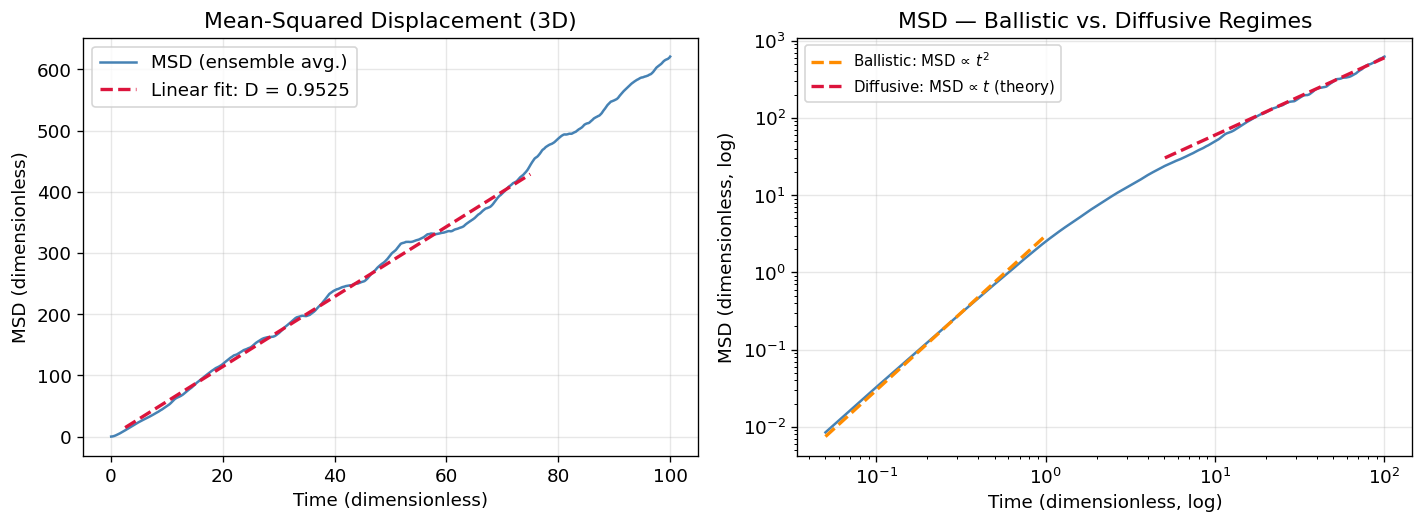

D (Einstein, MSD fit)    : 0.95250
D (theory, kBT/γm)       : 1.00000


In [9]:
# ── 3D Langevin diffusion: MSD ───────────────────────────────────────────────
N_diff   = 100     # number of independent walkers
N_steps_d = 2000
dt_d     = 0.05    # dimensionless
gamma_d  = 1.0
kBT_d    = 1.0
mass_d   = 1.0
D_theory = kBT_d / (gamma_d * mass_d)   # kBT / (γm) = 1 in dimensionless units

# Initialise
pos3 = np.zeros((N_diff, 3))
vel3 = rng.standard_normal((N_diff, 3)) * np.sqrt(kBT_d / mass_d)
r0   = pos3.copy()

msd   = np.zeros(N_steps_d)
pos_traj3 = np.zeros((N_steps_d, N_diff, 3))
vel_traj3 = np.zeros((N_steps_d, N_diff, 3))

noise_amp3 = np.sqrt(2.0 * gamma_d * kBT_d / mass_d)

for step in range(N_steps_d):
    xi = rng.standard_normal((N_diff, 3))
    force = -gamma_d * vel3 + noise_amp3 * xi / np.sqrt(dt_d)
    vel3  = vel3 + force * dt_d
    pos3  = pos3 + vel3 * dt_d
    pos_traj3[step] = pos3
    vel_traj3[step] = vel3
    dr2 = ((pos3 - r0)**2).sum(axis=1)    # MSD for each walker
    msd[step] = dr2.mean()

time_d = (np.arange(N_steps_d) + 1) * dt_d

# Fit linear region: from step 50 to 1500 (avoid ballistic & noisy tail)
fit_lo, fit_hi = 50, 1500
coeffs = np.polyfit(time_d[fit_lo:fit_hi], msd[fit_lo:fit_hi], 1)
D_einstein = coeffs[0] / (2 * 3)   # MSD = 6Dt → D = slope/6

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Linear scale
axes[0].plot(time_d, msd, lw=1.5, color='steelblue', label='MSD (ensemble avg.)')
axes[0].plot(time_d[fit_lo:fit_hi],
             np.polyval(coeffs, time_d[fit_lo:fit_hi]),
             '--', color='crimson', lw=2, label=f'Linear fit: D = {D_einstein:.4f}')
axes[0].set_xlabel('Time (dimensionless)')
axes[0].set_ylabel('MSD (dimensionless)')
axes[0].set_title('Mean-Squared Displacement (3D)')
axes[0].legend()

# Log-log scale
axes[1].loglog(time_d, msd, lw=1.5, color='steelblue')
t_ball = time_d[:20]
axes[1].loglog(t_ball, 3 * (kBT_d/mass_d) * t_ball**2, '--',
               color='darkorange', lw=2, label='Ballistic: MSD ∝ $t^2$')
t_diff = time_d[100:]
axes[1].loglog(t_diff, 6 * D_theory * t_diff, '--',
               color='crimson', lw=2, label='Diffusive: MSD ∝ $t$ (theory)')
axes[1].set_xlabel('Time (dimensionless, log)')
axes[1].set_ylabel('MSD (dimensionless, log)')
axes[1].set_title('MSD — Ballistic vs. Diffusive Regimes')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'D (Einstein, MSD fit)    : {D_einstein:.5f}')
print(f'D (theory, kBT/γm)       : {D_theory:.5f}')

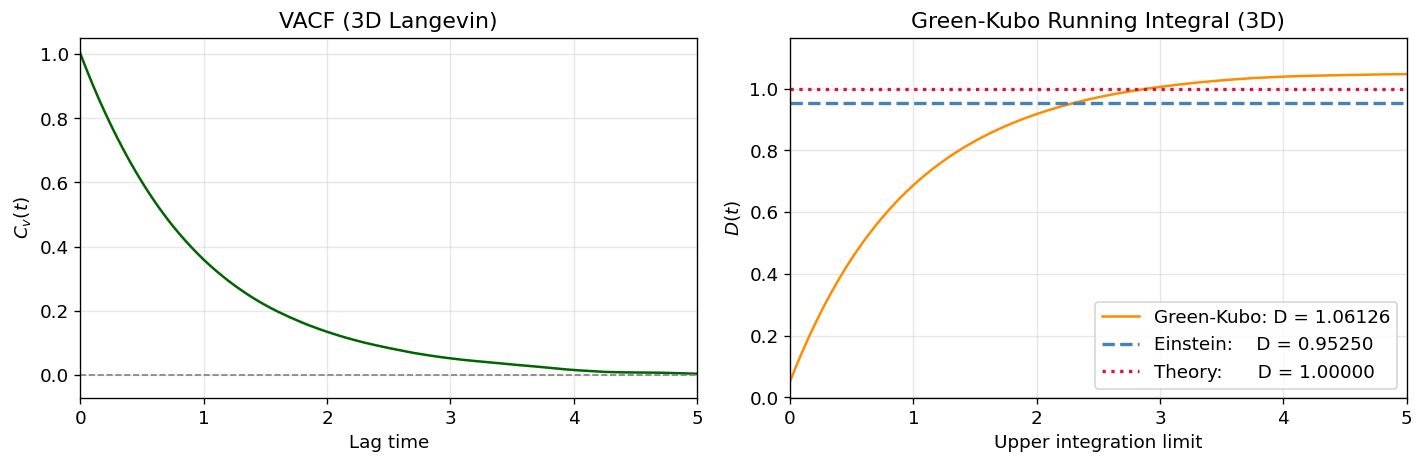

D (Green-Kubo integral)  : 1.06126
D (Einstein, MSD fit)    : 0.95250
D (theory, kBT/γm)       : 1.00000
GK / Einstein agreement  : 10.9% relative error


In [10]:
# ── Green-Kubo D from 3D trajectory ─────────────────────────────────────────
# Average VACF over all particles and all 3 components
v3_flat  = vel_traj3.reshape(N_steps_d, N_diff * 3)   # treat each component independently
N_max_gk = N_steps_d // 2
VACF_3d  = compute_vacf_fft(v3_flat, N_max_gk)

# D_GK = ∫₀^∞ <v_x(0) v_x(t)> dt   (1 component, already normalised × <v²>)
v2_mean_3d  = np.mean(vel_traj3**2)          # mean square speed per component
t_gk        = np.arange(N_max_gk) * dt_d
D_running3d = np.cumsum(VACF_3d * v2_mean_3d) * dt_d
D_GK_3d     = D_running3d[-50:].mean()        # converged value

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_gk, VACF_3d, lw=1.5, color='darkgreen')
axes[0].axhline(0, ls='--', color='gray', lw=1)
axes[0].set_xlim(0, min(5, t_gk[-1]))
axes[0].set_xlabel('Lag time')
axes[0].set_ylabel('$C_v(t)$')
axes[0].set_title('VACF (3D Langevin)')

axes[1].plot(t_gk, D_running3d, lw=1.5, color='darkorange',
             label=f'Green-Kubo: D = {D_GK_3d:.5f}')
axes[1].axhline(D_einstein, ls='--', color='steelblue', lw=2,
                label=f'Einstein:    D = {D_einstein:.5f}')
axes[1].axhline(D_theory, ls=':', color='crimson', lw=2,
                label=f'Theory:      D = {D_theory:.5f}')
axes[1].set_xlabel('Upper integration limit')
axes[1].set_ylabel('$D(t)$')
axes[1].set_title('Green-Kubo Running Integral (3D)')
axes[1].set_xlim(0, 5)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'D (Green-Kubo integral)  : {D_GK_3d:.5f}')
print(f'D (Einstein, MSD fit)    : {D_einstein:.5f}')
print(f'D (theory, kBT/γm)       : {D_theory:.5f}')
print(f'GK / Einstein agreement  : {abs(D_GK_3d - D_einstein)/D_theory*100:.1f}% relative error')

---
## Section 6: Block Averaging and Statistical Errors

### 6.1 The Problem with Correlated Samples

Consecutive MD frames are **not** independent: they are separated by $\Delta t_{\text{save}} \ll \tau_A$.
The naive estimate of the standard error,
$$\sigma_{\text{naive}} = \frac{\text{std}(A)}{\sqrt{N_{\text{frames}}}},$$
**underestimates** the true uncertainty by a factor of $\sqrt{2\tau_A/\Delta t_{\text{save}}}$.

### 6.2 Block Averaging

Divide the trajectory into $B$ non-overlapping blocks of length $\tau_{\text{block}}$:
$$\bar{A}_b = \frac{1}{\tau_{\text{block}}}\sum_{t \in \text{block}_b} A(t), \qquad b = 1, \ldots, B$$

When $\tau_{\text{block}} \gg \tau_A$, block averages are approximately independent.  The correct error:
$$\sigma_{\langle A\rangle} = \frac{\text{std}(\bar{A}_b)}{\sqrt{B}}$$

**Convergence test:** plot $\sigma$ vs. block size $\tau_{\text{block}}$.  The error:
1. Increases as $\tau_{\text{block}}$ grows (fewer, better independent blocks).
2. Reaches a **plateau** when $\tau_{\text{block}} > \tau_A$ — this is the correct error estimate.
3. Increases again at very large block sizes (too few blocks).

### 6.3 Related Methods

- **Bootstrap resampling**: randomly resample $B$ blocks with replacement; compute std of resampled means.
- **Jackknife**: leave-one-block-out estimate; less variance but more bias than bootstrap.
- **Autocorrelation-based correction**: explicitly compute $\tau_A$ and multiply naive error by
  $\sqrt{1 + 2\tau_A/\Delta t}$.

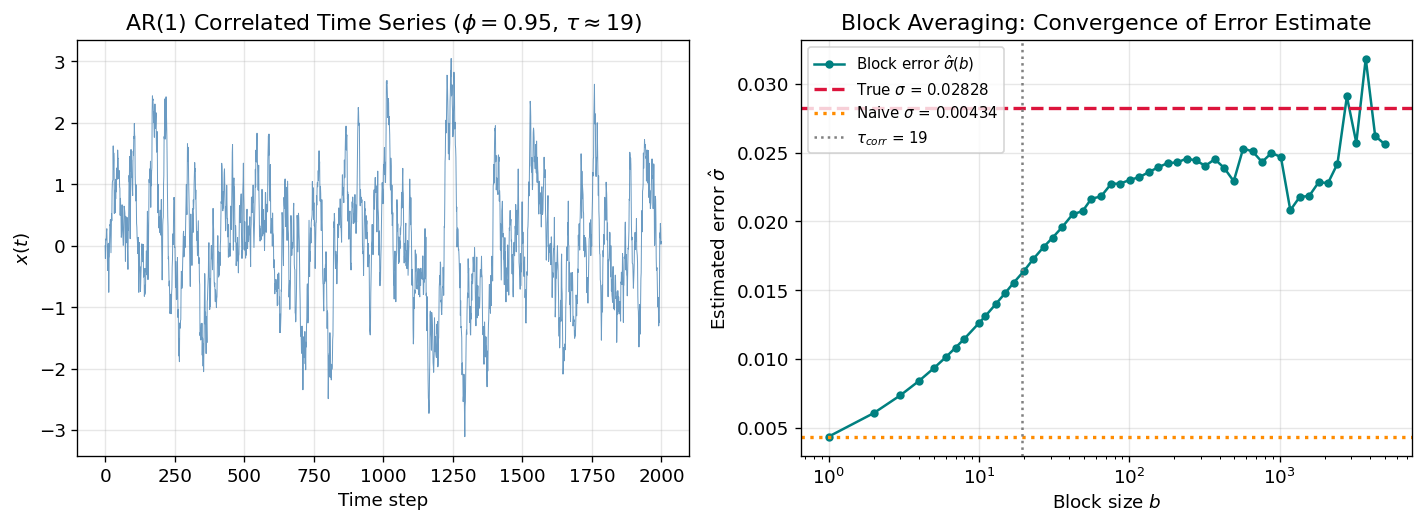

True autocorrelation time : τ = 19.5 steps
Naive σ (underestimate)   : 0.004343
True σ                    : 0.028281
Block average σ (plateau) : 0.023195
Underestimation factor    : 6.51×


In [11]:
# ── Generate a correlated time series (AR(1) process) ─────────────────────
# x(t+1) = φ * x(t) + ε(t),  ε ~ N(0, σ²)
# True mean = 0; true variance = σ² / (1 - φ²)
# Autocorrelation time: τ = -1/ln(φ)

N_ar   = 50_000
phi    = 0.95      # high autocorrelation
sigma_ar = np.sqrt(1 - phi**2)   # normalise so Var(x)=1
tau_true = -1.0 / np.log(phi)   # true autocorrelation time

x_ar = np.zeros(N_ar)
eps  = rng.standard_normal(N_ar) * sigma_ar
for t in range(1, N_ar):
    x_ar[t] = phi * x_ar[t-1] + eps[t]

# True standard error of the mean
# σ_true = sqrt(Var(x) * (1 + 2τ) / N)  ≈ sqrt(2τ/N) for large τ
sigma_true = np.sqrt((1.0 / N_ar) * (1 + 2 * tau_true))

# Naive estimate
sigma_naive = x_ar.std() / np.sqrt(N_ar)

# Block averaging over a range of block sizes
block_sizes = np.unique(np.geomspace(1, N_ar // 10, 60).astype(int))
block_errors = []
for bs in block_sizes:
    n_blocks = N_ar // bs
    if n_blocks < 2:
        block_errors.append(np.nan)
        continue
    blocks = x_ar[:n_blocks * bs].reshape(n_blocks, bs).mean(axis=1)
    block_errors.append(blocks.std() / np.sqrt(n_blocks))

block_errors = np.array(block_errors)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Time series
axes[0].plot(x_ar[:2000], lw=0.6, alpha=0.8, color='steelblue')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('$x(t)$')
axes[0].set_title(f'AR(1) Correlated Time Series ($\\phi={phi}$, $\\tau\\approx{tau_true:.0f}$)')

# Block error vs block size
axes[1].semilogx(block_sizes, block_errors, 'o-', ms=4, color='teal',
                 label='Block error $\\hat{\\sigma}(b)$')
axes[1].axhline(sigma_true, ls='--', color='crimson', lw=2,
                label=f'True $\\sigma$ = {sigma_true:.5f}')
axes[1].axhline(sigma_naive, ls=':', color='darkorange', lw=2,
                label=f'Naive $\\sigma$ = {sigma_naive:.5f}')
axes[1].axvline(tau_true, ls=':', color='gray', lw=1.5,
                label=f'$\\tau_{{corr}}$ = {tau_true:.0f}')
axes[1].set_xlabel('Block size $b$')
axes[1].set_ylabel('Estimated error $\\hat{\\sigma}$')
axes[1].set_title('Block Averaging: Convergence of Error Estimate')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Find plateau value
valid = ~np.isnan(block_errors)
plateau_mask = block_sizes[valid] > tau_true
plateau_val  = block_errors[valid][plateau_mask].mean() if plateau_mask.any() else np.nan

print(f'True autocorrelation time : τ = {tau_true:.1f} steps')
print(f'Naive σ (underestimate)   : {sigma_naive:.6f}')
print(f'True σ                    : {sigma_true:.6f}')
print(f'Block average σ (plateau) : {plateau_val:.6f}')
print(f'Underestimation factor    : {sigma_true/sigma_naive:.2f}×')

---
## Summary

### Key Takeaways

| Topic | Key Concept |
|---|---|
| **Equilibration** | Monitor energy/T/ρ; use block averaging and autocorrelation times |
| **Temperature** | $T = 2\langle KE\rangle / (N_{dof} k_B)$; equipartition |
| **Pressure** | Virial theorem: $PV = Nk_BT + \tfrac{1}{3}\langle\mathbf{r}\cdot\mathbf{F}\rangle$ |
| **Heat capacity** | $C_V = \langle(\delta E)^2\rangle / (k_BT^2)$ from fluctuations |
| **$g(r)$** | Normalised pair density; peaks at preferred distances; $n_1$ = coordination number |
| **VACF** | $C_v(t) = \langle v(0)v(t)\rangle/\langle v^2\rangle$; FFT → VDOS |
| **MSD** | MSD = $2dDt$ (diffusive); fit slope to get $D$ (Einstein) |
| **Green-Kubo** | $D = \int_0^\infty C_v(t)\langle v^2\rangle\,dt$; agrees with Einstein |
| **Block averaging** | Essential for correlated data; plateau in $\hat{\sigma}$ vs block size |

**Workflow for a new MD trajectory:**
1. Inspect energy / temperature / density → identify equilibration time.
2. Compute $g(r)$ → check structure, coordination, phase.
3. Compute MSD → extract $D$; verify diffusive regime.
4. Compute VACF + FFT → VDOS, spectroscopic comparison.
5. Block-average every reported observable → reliable error bars.

---
## References

1. **Frenkel, D. & Smit, B.** *Understanding Molecular Simulation: From Algorithms to Applications*,
   2nd ed. Academic Press, 2002.  
   → Chapters 4 (MC), 6 (MD), 7 (free energy), 4.4 (block averaging).

2. **Allen, M. P. & Tildesley, D. J.** *Computer Simulation of Liquids*, 2nd ed. Oxford, 2017.  
   → Chapters 2–3 for MD; Chapter 7 for time-correlation functions.

3. **Tuckerman, M. E.** *Statistical Mechanics: Theory and Molecular Simulation*. Oxford, 2010.  
   → Rigorous derivations of Green-Kubo relations and Langevin dynamics.

4. **Rapaport, D. C.** *The Art of Molecular Dynamics Simulation*, 2nd ed. Cambridge, 2004.

5. **NIST WebBook** — Experimental diffusion coefficients and thermodynamic data:  
   https://webbook.nist.gov/

6. **MDAnalysis** — Python library for trajectory analysis:  
   Michaud-Agrawal et al., *J. Comput. Chem.* **32**, 2319–2327 (2011).  
   https://www.mdanalysis.org/

7. **LAMMPS / GROMACS / NAMD / OpenMM** — Production MD engines used in research and industry.